# Linear Discriminant Analysis (LDA) for Dimensionality Reduction

**Goal:** Understand how LDA finds axes that maximise class separability, and apply it to reduce dimensions.

## What you will do

- Generate synthetic 3‑class data in 2 dimensions (easily visualisable).
- Compute **within‑class scatter matrix** \(S_W\) and **between‑class scatter matrix** \(S_B\).
- Solve the generalised eigenvalue problem \(S_W^{-1} S_B \mathbf{v} = \lambda \mathbf{v}\).
- Sort eigenvectors by eigenvalues (largest = most discriminative direction).
- Project data onto the top 1 or 2 discriminant directions.
- Compare with scikit‑learn’s `LinearDiscriminantAnalysis`.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Generate 3 well‑separated clusters (classes)
X, y = make_blobs(n_samples=200, centers=3, n_features=2,
                  cluster_std=1.5, random_state=42)

print("Data shape:", X.shape)
print("Unique labels:", np.unique(y))

Data shape: (200, 2)
Unique labels: [0 1 2]


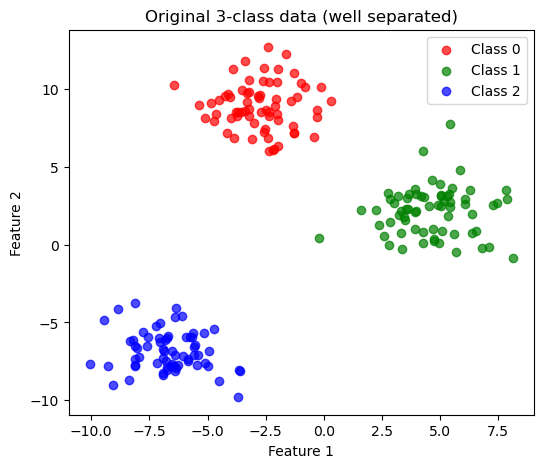

In [3]:
plt.figure(figsize=(6,5))
colors = ['red', 'green', 'blue']
for label in np.unique(y):
    plt.scatter(X[y==label, 0], X[y==label, 1],
                c=colors[label], alpha=0.7, label=f'Class {label}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original 3‑class data (well separated)')
plt.legend()
plt.show()

In [5]:
overall_mean = np.mean(X, axis=0)
class_means = {}
for label in np.unique(y):
    class_means[label] = np.mean(X[y==label], axis=0)

print("Overall mean:", overall_mean)
print("Class means:")
for k, v in class_means.items():
    print(f"  Class {k}: {v}")

Overall mean: [-1.56910665  1.46039271]
Class means:
  Class 0: [-2.73363312  8.92920925]
  Class 1: [4.628334   2.16523582]
  Class 2: [-6.67827712 -6.83711026]


In [7]:
n_features = X.shape[1]
S_W = np.zeros((n_features, n_features))
for label in np.unique(y):
    X_c = X[y==label]
    mu_c = class_means[label]
    for x in X_c:
        diff = (x - mu_c).reshape(-1,1)
        S_W += diff @ diff.T

print("Within‑class scatter matrix S_W:\n", S_W)

Within‑class scatter matrix S_W:
 [[409.26919643 -13.93730309]
 [-13.93730309 410.79577607]]


In [9]:
n_samples = len(y)
S_B = np.zeros((n_features, n_features))
for label in np.unique(y):
    n_c = np.sum(y==label)
    diff = (class_means[label] - overall_mean).reshape(-1,1)
    S_B += n_c * (diff @ diff.T)

print("Between‑class scatter matrix S_B:\n", S_B)

Between‑class scatter matrix S_B:
 [[4387.05340252 2507.891015  ]
 [2507.891015   8314.76629739]]


In [11]:
# Compute eigenvectors and eigenvalues of inv(S_W) @ S_B
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(S_W) @ S_B)

# Convert to real numbers (there may be small imaginary parts due to numerical errors)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort eigenvalues in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", eigenvalues)
print("First eigenvector (most discriminant):", eigenvectors[:,0])

Eigenvalues: [23.8861701   7.52578956]
First eigenvector (most discriminant): [-0.4663349  -0.88460825]


In [13]:
# Project onto first discriminant axis (1D)
X_lda1 = X @ eigenvectors[:, 0].reshape(-1,1)

# Project onto first two discriminant axes (2D)
X_lda2 = X @ eigenvectors[:, :2]

print("Projected shape (1D):", X_lda1.shape)
print("Projected shape (2D):", X_lda2.shape)

Projected shape (1D): (200, 1)
Projected shape (2D): (200, 2)


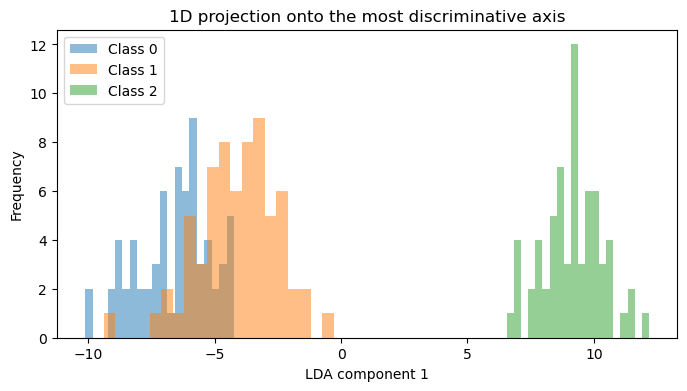

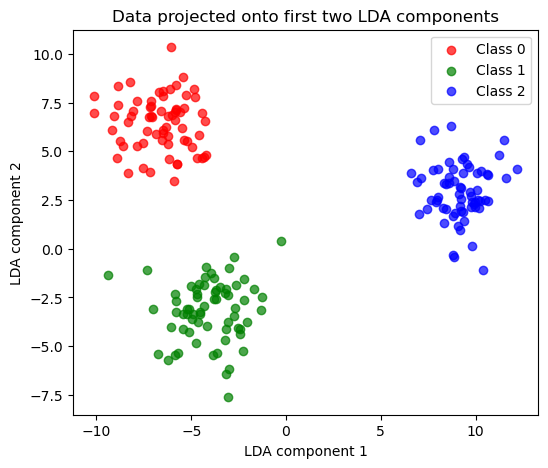

In [15]:
# 1D projection (histograms per class)
plt.figure(figsize=(8,4))
for label in np.unique(y):
    plt.hist(X_lda1[y==label, 0], bins=20, alpha=0.5, label=f'Class {label}')
plt.xlabel('LDA component 1')
plt.ylabel('Frequency')
plt.title('1D projection onto the most discriminative axis')
plt.legend()
plt.show()

# 2D projection
plt.figure(figsize=(6,5))
for label in np.unique(y):
    plt.scatter(X_lda2[y==label, 0], X_lda2[y==label, 1],
                c=colors[label], alpha=0.7, label=f'Class {label}')
plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')
plt.title('Data projected onto first two LDA components')
plt.legend()
plt.show()

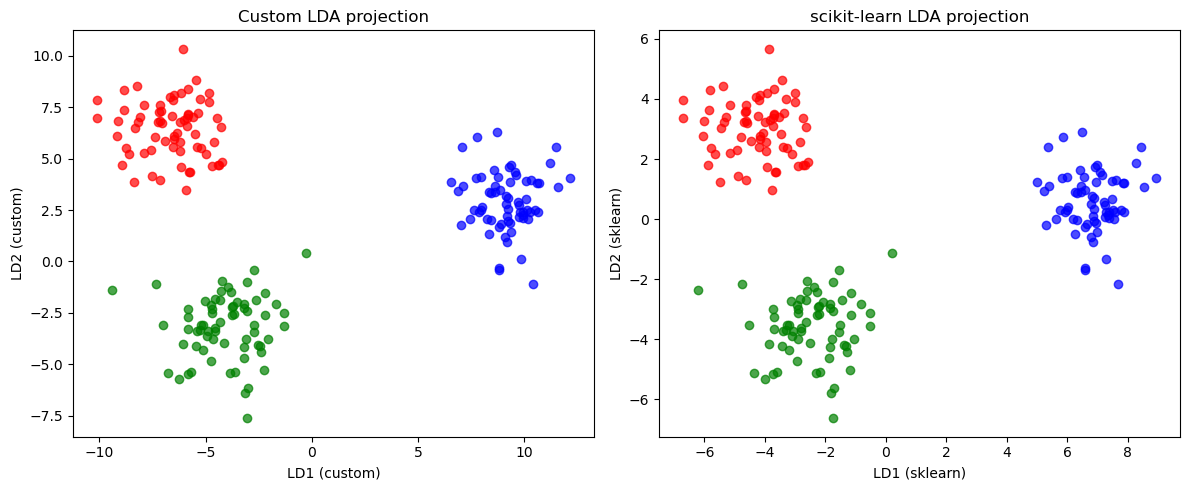

In [17]:
# Use sklearn’s LDA to get the same transformation
lda_sklearn = LinearDiscriminantAnalysis(n_components=2)
X_sklearn = lda_sklearn.fit_transform(X, y)

# Compare projections
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for label in np.unique(y):
    plt.scatter(X_lda2[y==label, 0], X_lda2[y==label, 1],
                c=colors[label], alpha=0.7)
plt.xlabel('LD1 (custom)')
plt.ylabel('LD2 (custom)')
plt.title('Custom LDA projection')

plt.subplot(1,2,2)
for label in np.unique(y):
    plt.scatter(X_sklearn[y==label, 0], X_sklearn[y==label, 1],
                c=colors[label], alpha=0.7)
plt.xlabel('LD1 (sklearn)')
plt.ylabel('LD2 (sklearn)')
plt.title('scikit‑learn LDA projection')

plt.tight_layout()
plt.show()

## Questions to Answer

1. **What does LDA optimise?** How is it different from PCA?

2. **Why do we need to compute \(S_W^{-1} S_B\)?** What do the eigenvectors represent?

3. **For a C‑class problem, what is the maximum number of discriminant axes we can obtain?** Why?

4. **Look at the 1D histogram projection.** Are the classes well separated? Why?

5. **How would you use LDA as a classifier?** (Explain briefly.)

Write your answers below.